In [1]:
# Week 3 SVM - Project

In [2]:
# Import neccesary libraries 
import pandas as pd # data manipulation
import numpy as np # vectorized math 
import seaborn as sns # visualization tool
import matplotlib.pyplot as plt # visualization tool

In [3]:
# import specified dataset from seaborn
iris = sns.load_dataset('iris')

# view result 
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
# shape of dataset 
iris.shape

(150, 5)

In [5]:
# Info 
iris.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


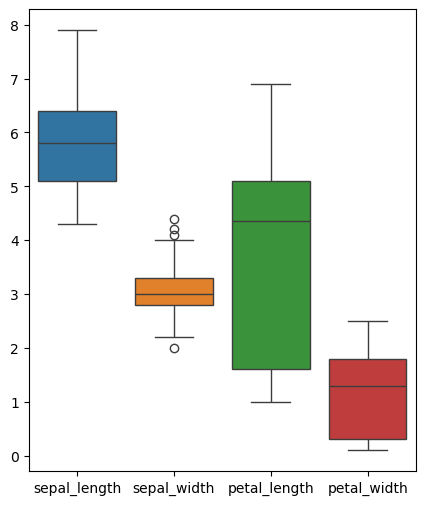

In [6]:
# look for outliers (whisker plot)
plt.figure(figsize=(5,6)) # size of plot 
sns.boxplot(data= iris)
plt.show()

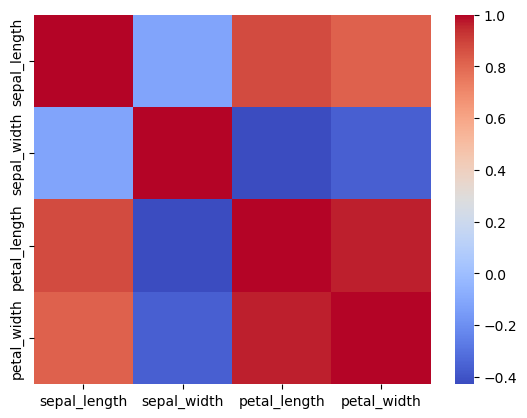

In [7]:
# create a correlation matrix heat map (correaltion analyis)

corr = iris.corr(numeric_only= True) # filter str columns 


# heatmap
sns.heatmap(corr, annot = False, cmap = 'coolwarm' )
plt.show()

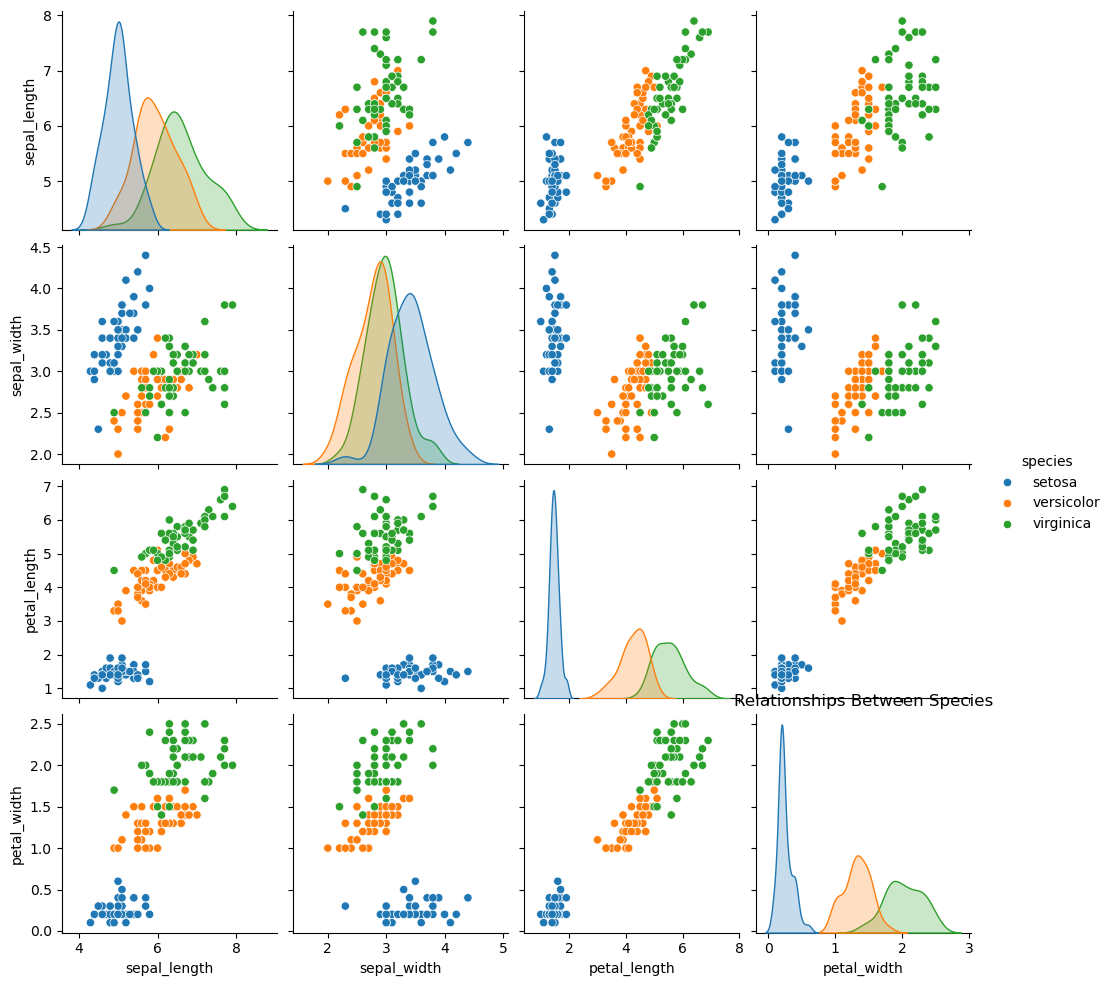

In [8]:
# Use pairplot visualization to interpret relationships/similarities between the variables 
sns.pairplot(data = iris, hue= 'species')
plt.title('Relationships Between Species')
plt.show() 

In [9]:
# numerical viewing of correlation between variables
iris.corr(numeric_only= True,)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.117570,0.871754,0.817941
sepal_width,-0.117570,1.000000,-0.428440,-0.366126
petal_length,0.871754,-0.428440,1.000000,0.962865
petal_width,0.817941,-0.366126,0.962865,1.000000


In [10]:
# kendall correlation
iris.corr('kendall', numeric_only= True)

,sepal_length,sepal_width,petal_length,petal_width
sepal_length,1.000000,-0.076997,0.718516,0.655309
sepal_width,-0.076997,1.000000,-0.185994,-0.157126
petal_length,0.718516,-0.185994,1.000000,0.806891
petal_width,0.655309,-0.157126,0.806891,1.000000


In [11]:
# training phase (train the model on the relationships -> test on it's performance) 
from sklearn.model_selection import train_test_split

#  inputs/features (drop target variable to avoid data leakage)
X = iris.drop(columns = ['species']) 

# target variable
Y = iris['species']

# 70/30 split 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size= 0.3, random_state= 42)


In [12]:
# Modeling phase (predict which class each row likely fits in)
from sklearn.svm import SVC

# instantiation process
model = SVC()

# fit data onto model 
model.fit(X_train, Y_train)

# predict 
y_prediction = model.predict(X_test)

# prediction results 
print(y_prediction)

['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'setosa']


In [13]:
# Performance Metrics (Evaluate models performance)
from sklearn.metrics import confusion_matrix, classification_report

print(f'Confusion Matrix {confusion_matrix(Y_test, y_prediction)}')
print(f'Classification Report {classification_report(Y_test, y_prediction)}')

Confusion Matrix [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [20]:
# hyper tunning phase (find the optimal knobs to turn on the model)
from sklearn.model_selection import GridSearchCV 

# fit paramas into object 
params = {"C": [1, 10, 100, 1000],
          "gamma": [1.0, 0.1, 0.01, 0.001, 0.0001]}

# instantiation process
grid = GridSearchCV(model, params, cv = 5, verbose = 5)

# fit data onto model 
grid.fit(X_train, Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV 1/5] END ....................C=1, gamma=1.0;, score=0.952 total time=   0.0s
[CV 2/5] END ....................C=1, gamma=1.0;, score=0.905 total time=   0.0s
[CV 3/5] END ....................C=1, gamma=1.0;, score=0.905 total time=   0.0s
[CV 4/5] END ....................C=1, gamma=1.0;, score=1.000 total time=   0.0s
[CV 5/5] END ....................C=1, gamma=1.0;, score=0.952 total time=   0.0s
[CV 1/5] END ....................C=1, gamma=0.1;, score=1.000 total time=   0.0s
[CV 2/5] END ....................C=1, gamma=0.1;, score=0.905 total time=   0.0s
[CV 3/5] END ....................C=1, gamma=0.1;, score=0.905 total time=   0.0s
[CV 4/5] END ....................C=1, gamma=0.1;, score=1.000 total time=   0.0s
[CV 5/5] END ....................C=1, gamma=0.1;, score=0.952 total time=   0.0s
[CV 1/5] END ...................C=1, gamma=0.01;, score=1.000 total time=   0.0s
[CV 2/5] END ...................C=1, gamma=0.01

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': [1, 10, 100, 1000],
                         'gamma': [1.0, 0.1, 0.01, 0.001, 0.0001]},
             verbose=5)

In [22]:
# best parameters 
print(f'Best Params{grid.best_params_}')

Best Params{'C': 100, 'gamma': 0.01}


In [23]:
# predictions 
Y_predictions = grid.predict(X_test)

# results
print(Y_predictions)

['versicolor' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'versicolor' 'virginica' 'versicolor' 'versicolor' 'virginica' 'setosa'
 'setosa' 'setosa' 'setosa' 'versicolor' 'virginica' 'versicolor'
 'versicolor' 'virginica' 'setosa' 'virginica' 'setosa' 'virginica'
 'virginica' 'virginica' 'virginica' 'virginica' 'setosa' 'setosa'
 'setosa' 'setosa' 'versicolor' 'setosa' 'setosa' 'virginica' 'versicolor'
 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'versicolor' 'setosa'
 'setosa']


In [26]:
# Evalaute Hyper Tunning Performance 
print(f'Classification Report {classification_report(Y_test, Y_predictions)}')
print(f'Confusion Matrix {confusion_matrix(Y_test, Y_predictions)}')

Classification Report               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix [[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
